In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

datasets = [
"/content/drive/MyDrive/Pepper.zip",
"/content/drive/MyDrive/Potato.zip",
"/content/drive/MyDrive/Tomato.zip"
]

extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

for zip_path in datasets:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("All datasets extracted!")

All datasets extracted!


In [4]:
import shutil
from sklearn.model_selection import train_test_split

base_dir = "/content/dataset"

train_dir = "/content/train"
val_dir = "/content/val"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

for crop in os.listdir(base_dir):

    crop_path = os.path.join(base_dir, crop)

    if os.path.isdir(crop_path):

        for disease in os.listdir(crop_path):

            disease_path = os.path.join(crop_path, disease)

            images = os.listdir(disease_path)

            train_imgs, val_imgs = train_test_split(
                images,
                test_size=0.2,
                random_state=42
            )

            os.makedirs(os.path.join(train_dir, disease), exist_ok=True)
            os.makedirs(os.path.join(val_dir, disease), exist_ok=True)

            for img in train_imgs:
                shutil.copy(
                    os.path.join(disease_path, img),
                    os.path.join(train_dir, disease, img)
                )

            for img in val_imgs:
                shutil.copy(
                    os.path.join(disease_path, img),
                    os.path.join(val_dir, disease, img)
                )

print("Train-Val split complete!")

Train-Val split complete!


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.6,1.4],
    shear_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 16504 images belonging to 15 classes.
Found 4134 images belonging to 15 classes.


In [6]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)

output = Dense(
    train_generator.num_classes,
    activation="softmax"
)(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,068,786 (15.52 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [7]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array(train_generator.classes)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)

class_weights_dict = dict(enumerate(class_weights))

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
monitor="val_loss",
patience=4,
restore_best_weights=True
)

checkpoint = ModelCheckpoint(
"best_crop_model.keras",
monitor="val_accuracy",
save_best_only=True
)

history = model.fit(
train_generator,
validation_data=val_generator,
epochs=50,
class_weight=class_weights_dict,
callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 328s 571ms/step - accuracy: 0.1898 - loss: 2.5941 - val_accuracy: 0.6033 - val_loss: 1.7947
Epoch 2/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 254s 493ms/step - accuracy: 0.5493 - loss: 1.7692 - val_accuracy: 0.7097 - val_loss: 1.3682
Epoch 3/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 254s 492ms/step - accuracy: 0.6507 - loss: 1.4075 - val_accuracy: 0.7499 - val_loss: 1.1266
Epoch 4/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 259s 502ms/step - accuracy: 0.6945 - loss: 1.1927 - val_accuracy: 0.7791 - val_loss: 0.9741
Epoch 5/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 259s 501ms/step - accuracy: 0.7333 - loss: 1.0282 - val_accuracy: 0.7949 - val_loss: 0.8744
Epoch 6/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 258s 499ms/step - accuracy: 0.7502 - loss: 0.9516 - val_accuracy: 0.8060 - val_loss: 0.7945
Epoch 7/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 255s 494ms/step - accuracy: 0.7693 - loss: 0.8618 - val_accuracy: 0.8205 - val_loss: 0.7372
Epoch 8/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 256s 496ms/step - accuracy: 0.7801 -

In [9]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
optimizer=tf.keras.optimizers.Adam(1e-5),
loss="categorical_crossentropy",
metrics=["accuracy"]
)

model.fit(
train_generator,
validation_data=val_generator,
epochs=10
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 319s 557ms/step - accuracy: 0.7553 - loss: 0.7841 - val_accuracy: 0.9071 - val_loss: 0.3137
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 260s 504ms/step - accuracy: 0.8474 - loss: 0.4798 - val_accuracy: 0.9187 - val_loss: 0.2665
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 260s 504ms/step - accuracy: 0.8711 - loss: 0.4047 - val_accuracy: 0.9255 - val_loss: 0.2365
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 262s 508ms/step - accuracy: 0.8844 - loss: 0.3576 - val_accuracy: 0.9311 - val_loss: 0.2176
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 263s 509ms/step - accuracy: 0.8926 - loss: 0.3213 - val_accuracy: 0.9344 - val_loss: 0.2033
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 258s 499ms/step - accuracy: 0.9061 - loss: 0.2858 - val_accuracy: 0.9352 - val_loss: 0.1945
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 258s 500ms/step - accuracy: 0.9092 - loss: 0.2857 - val_accuracy: 0.9417 - val_loss: 0.1761
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 257s 499ms/step - accuracy: 0.9145 -

In [12]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "/content/dataset/Tomato/Tomato_healthy/01700b46-3800-46c6-ab81-09a5f50af525___RS_HL 0108.JPG"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

img_array = preprocess_input(img_array)

prediction = model.predict(img_array)

class_names = list(train_generator.class_indices.keys())

print("Prediction:", class_names[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction: Tomato_healthy


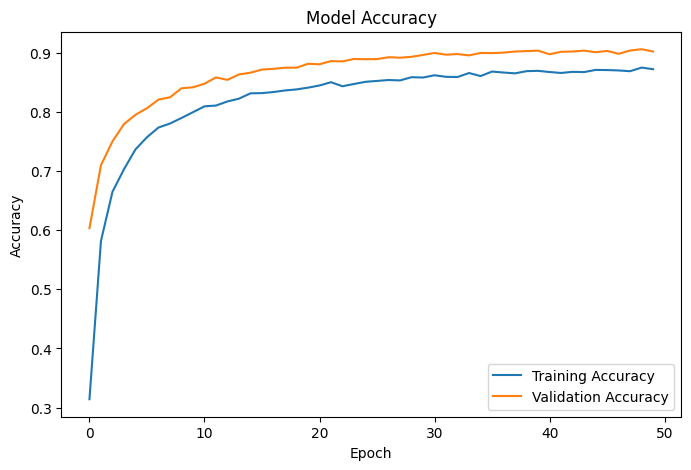

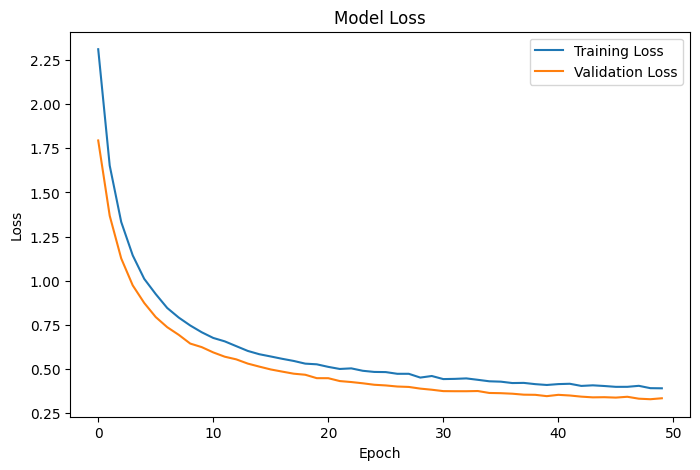

In [13]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

130/130 ━━━━━━━━━━━━━━━━━━━━ 16s 124ms/step


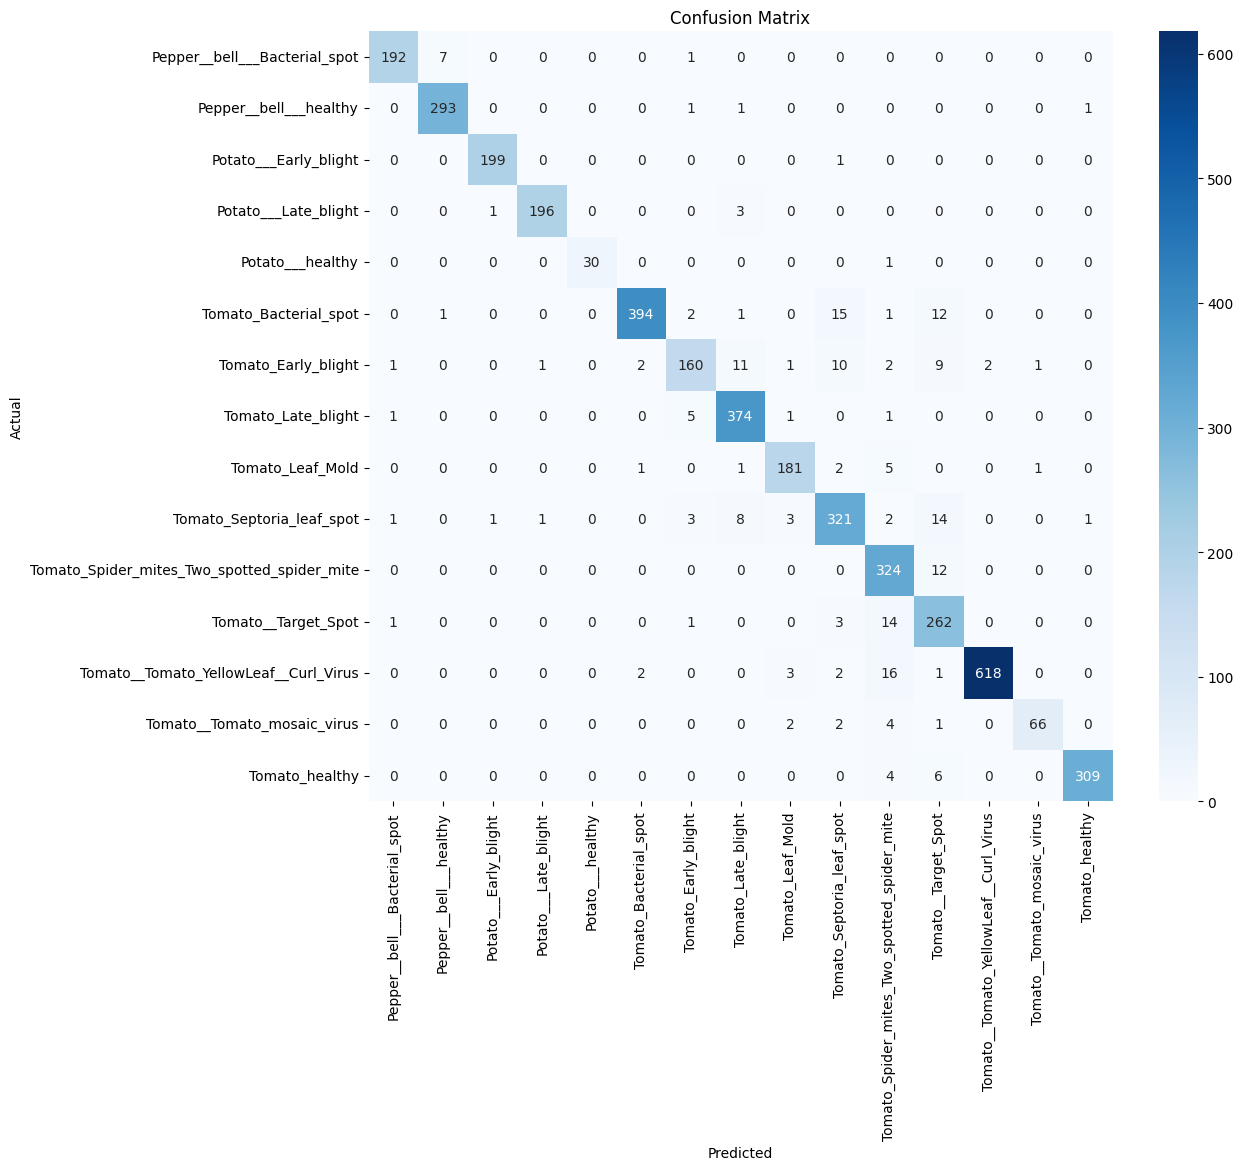

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

val_generator.reset()

Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)

class_labels = list(val_generator.class_indices.keys())

plt.figure(figsize=(12,10))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_labels
)

print("Classification Report:\n")
print(report)

Classification Report:

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      0.96      0.97       200
                     Pepper__bell___healthy       0.97      0.99      0.98       296
                      Potato___Early_blight       0.99      0.99      0.99       200
                       Potato___Late_blight       0.99      0.98      0.98       200
                           Potato___healthy       1.00      0.97      0.98        31
                      Tomato_Bacterial_spot       0.99      0.92      0.96       426
                        Tomato_Early_blight       0.92      0.80      0.86       200
                         Tomato_Late_blight       0.94      0.98      0.96       382
                           Tomato_Leaf_Mold       0.95      0.95      0.95       191
                  Tomato_Septoria_leaf_spot       0.90      0.90      0.90       355
Tomato_Spider_mites_Two_spotted_spider_m

Actual Class: Potato___healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Predicted Class: Potato___healthy
Confidence: 94.61%


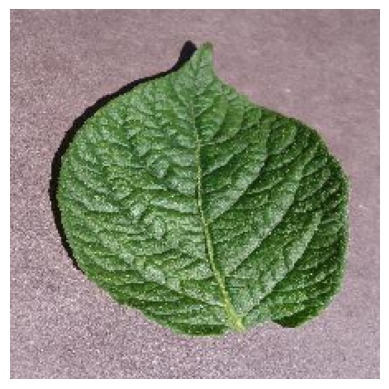

In [20]:
import random
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

# Pick random image from validation set
class_folders = [
    f for f in os.listdir(val_dir)
    if os.path.isdir(os.path.join(val_dir, f))
]

random_class = random.choice(class_folders)

random_image = random.choice(
    os.listdir(os.path.join(val_dir, random_class))
)

img_path = os.path.join(val_dir, random_class, random_image)

print("Actual Class:", random_class)

# Load image
img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis("off")

# Preprocess
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict
prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)

predicted_class = class_labels[predicted_index]

confidence = prediction[0][predicted_index] * 100

print("Predicted Class:", predicted_class)
print("Confidence: {:.2f}%".format(confidence))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


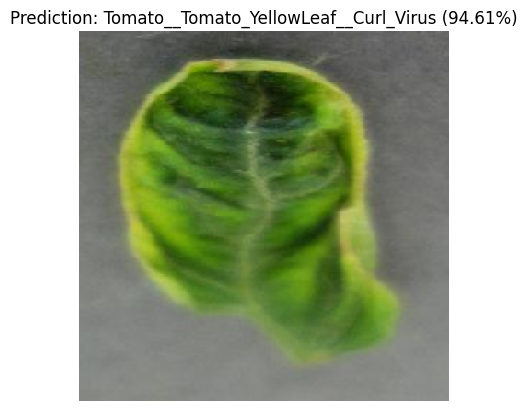

Actual: Tomato__Tomato_YellowLeaf__Curl_Virus
Predicted: Tomato__Tomato_YellowLeaf__Curl_Virus
------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


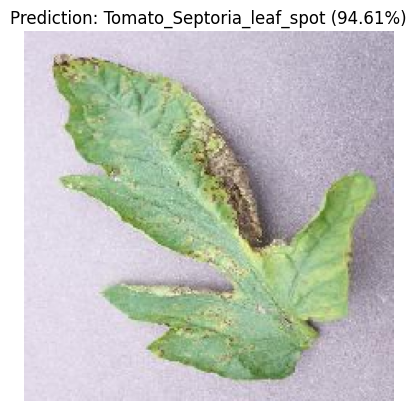

Actual: Tomato_Septoria_leaf_spot
Predicted: Tomato_Septoria_leaf_spot
------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


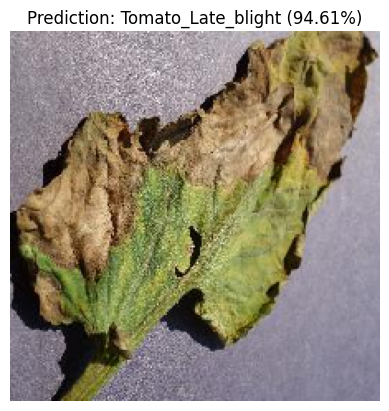

Actual: Tomato_Late_blight
Predicted: Tomato_Late_blight
------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


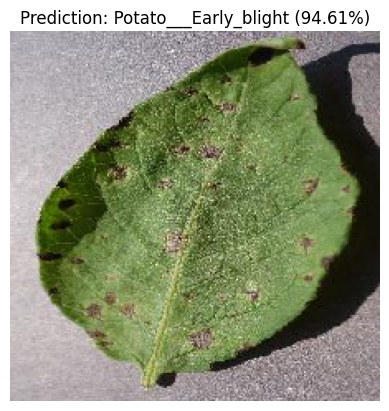

Actual: Potato___Early_blight
Predicted: Potato___Early_blight
------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


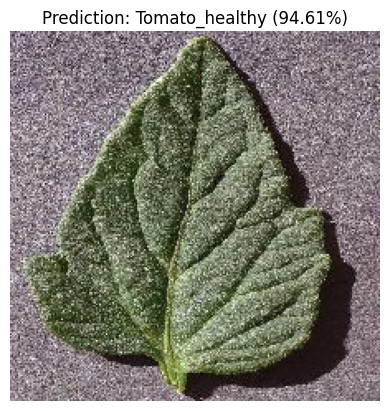

Actual: Tomato_healthy
Predicted: Tomato_healthy
------


In [22]:
for i in range(5):

    random_class = random.choice(class_folders)
    random_image = random.choice(
        os.listdir(os.path.join(val_dir, random_class))
    )

    img_path = os.path.join(val_dir, random_class, random_image)

    img = image.load_img(img_path, target_size=(224,224))

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array)

    predicted_class = class_labels[np.argmax(prediction)]

    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

    print("Actual:", random_class)
    print("Predicted:", predicted_class)
    print("------")

In [23]:
model.save("/content/drive/MyDrive/crop_disease_model.keras")

In [25]:
pip install opencv-python

In [26]:
import cv2
import numpy as np

def estimate_severity(image_path):

    img = cv2.imread(image_path)

    img = cv2.resize(img,(224,224))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # detect brown/yellow disease spots
    lower = np.array([10,50,50])
    upper = np.array([35,255,255])

    mask = cv2.inRange(hsv, lower, upper)

    infected_pixels = np.sum(mask > 0)

    total_pixels = mask.size

    severity = (infected_pixels / total_pixels) * 100

    return severity

In [28]:
severity = estimate_severity("/content/val/Tomato_Late_blight/01a68044-9c5b-4658-a944-6108c6862ce7___GHLB Leaf 2.1 Day 16.JPG")

print("Disease Severity:", severity,"%")

Disease Severity: 3.8743622448979593 %


In [29]:
def severity_level(severity):

    if severity < 10:
        return "Mild"

    elif severity < 30:
        return "Moderate"

    elif severity < 60:
        return "Severe"

    else:
        return "Critical"

In [30]:
level = severity_level(severity)

print("Severity Level:", level)

Severity Level: Mild


Class: Pepper__bell___Bacterial_spot
Severity: 2.76%
Severity Level: Mild


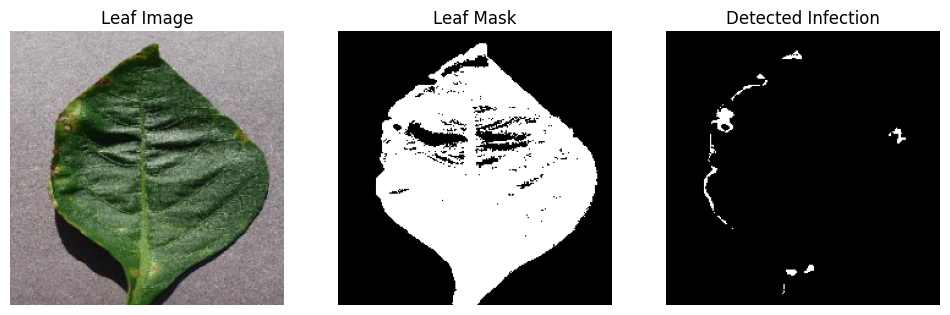

---------------------------
Class: Tomato_Leaf_Mold
Severity: 0.18%
Severity Level: Mild


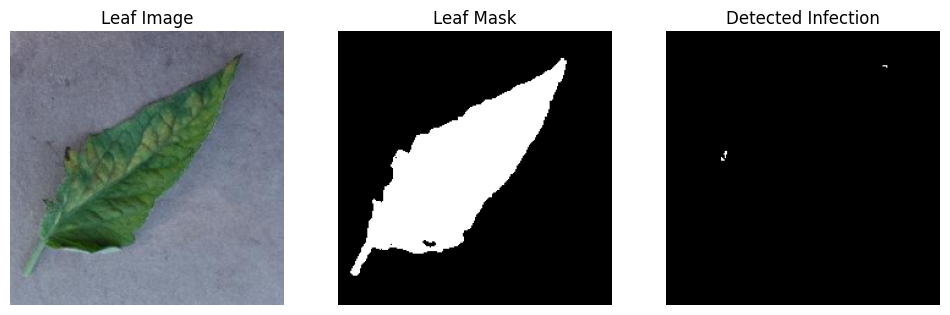

---------------------------
Class: Pepper__bell___healthy
Severity: 0.13%
Severity Level: Mild


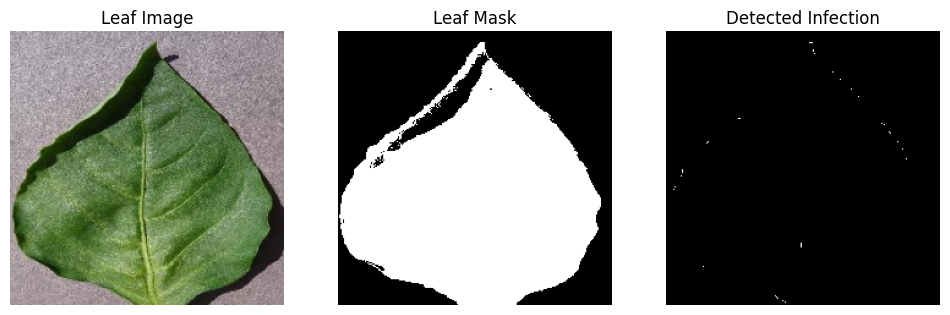

---------------------------
Class: Tomato_Spider_mites_Two_spotted_spider_mite
Severity: 1.39%
Severity Level: Mild


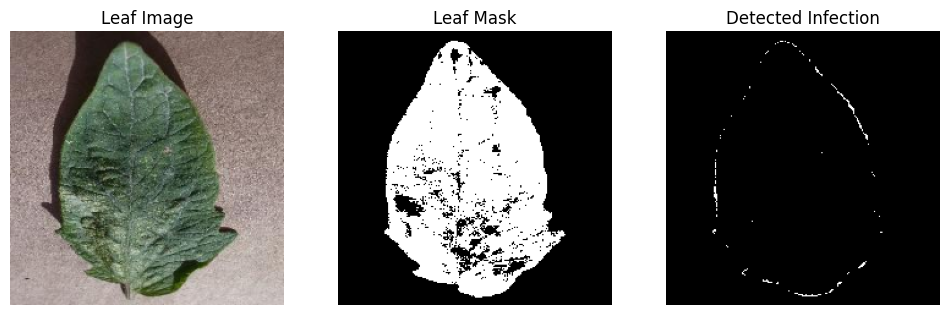

---------------------------
Class: Pepper__bell___Bacterial_spot
Severity: 1.73%
Severity Level: Mild


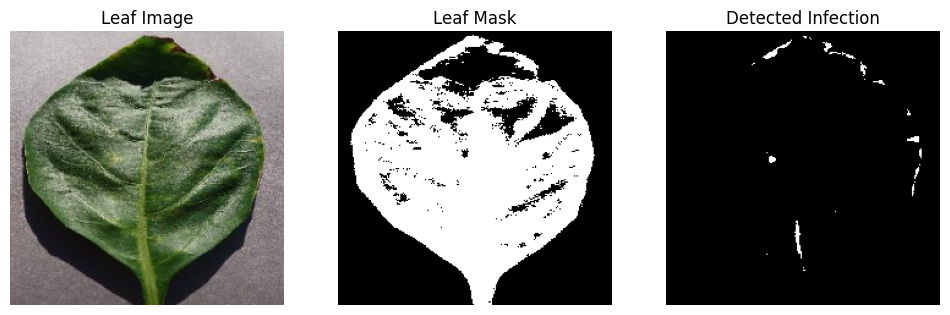

---------------------------


In [33]:
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt

val_dir = "/content/val"   # change if needed

# get only folders
class_folders = [
    f for f in os.listdir(val_dir)
    if os.path.isdir(os.path.join(val_dir, f))
]

for i in range(5):

    # pick random class
    random_class = random.choice(class_folders)

    # pick random image
    img_name = random.choice(
        os.listdir(os.path.join(val_dir, random_class))
    )

    img_path = os.path.join(val_dir, random_class, img_name)

    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.resize(img,(224,224))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # detect green leaf
    lower_leaf = np.array([25,40,40])
    upper_leaf = np.array([90,255,255])

    leaf_mask = cv2.inRange(hsv, lower_leaf, upper_leaf)

    # detect disease spots (yellow/brown)
    lower_disease = np.array([10,50,50])
    upper_disease = np.array([35,255,255])

    disease_mask = cv2.inRange(hsv, lower_disease, upper_disease)

    # keep disease only inside leaf
    infection_mask = cv2.bitwise_and(disease_mask, leaf_mask)

    infected_pixels = np.sum(infection_mask > 0)
    leaf_pixels = np.sum(leaf_mask > 0)

    if leaf_pixels == 0:
        severity = 0
    else:
        severity = (infected_pixels / leaf_pixels) * 100

    # severity level
    if severity < 10:
        level = "Mild"
    elif severity < 30:
        level = "Moderate"
    elif severity < 60:
        level = "Severe"
    else:
        level = "Critical"

    print("Class:", random_class)
    print("Severity: {:.2f}%".format(severity))
    print("Severity Level:", level)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.title("Leaf Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(leaf_mask,cmap="gray")
    plt.title("Leaf Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(infection_mask,cmap="gray")
    plt.title("Detected Infection")
    plt.axis("off")

    plt.show()

    print("---------------------------")

In [34]:
def estimate_yield_loss(crop, severity):

    crop_factors = {
        "Tomato":0.45,
        "Potato":0.55,
        "Pepper":0.40
    }

    factor = crop_factors.get(crop,0.45)

    yield_loss = severity * factor

    return yield_loss

In [37]:
crop = random_class

yield_loss = estimate_yield_loss(crop, severity)

print("Crop:", crop)
print("Predicted Yield Loss: {:.2f}%".format(yield_loss))

Crop: Pepper__bell___Bacterial_spot
Predicted Yield Loss: 0.78%
